# LOAD LIBRARY

In [1]:
# Library preprocessing text
import pandas as pd
from datetime import datetime
import os
import re

# Library bar chart dan wordcloud
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Library stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Library IndoBERT (analisis sentimen)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

d:\Limit\Intric\scraper\hxrscraper\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PREPROCESSING

In [2]:
project_name = "sufmi_dasco_2"
file_name = f"{project_name}-tweets.csv"

# SETUP FOLDER
base_folder = f"../../result/{project_name}/tweets"
output_folder = f"{base_folder}/preprocessing"
os.makedirs(output_folder, exist_ok=True)

data = pd.read_csv(f"{base_folder}/{file_name}")

# Konversi kolom created_at ke datetime aware dan ubah ke zona waktu Asia/Jakarta
data['created_at'] = pd.to_datetime(
    data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
).dt.tz_convert('Asia/Jakarta').dt.strftime('%a %b %d %H:%M:%S %z %Y')

# Cek kolom tanggal & waktu ada. Jika belum, buat.
if 'tanggal' not in data.columns or 'waktu' not in data.columns:
    data['tanggal'] = pd.to_datetime(
        data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
    ).dt.strftime('%Y-%m-%d')

    data['waktu'] = pd.to_datetime(
        data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
    ).dt.strftime('%H:%M:%S')

    df = pd.DataFrame(data[[
        'tweet_id_str','created_at','tanggal','waktu',
        'user_id_str','username','name',
        'user_mentions','hashtags','location','lang',
        'quote_count','views_count','favorite_count','reply_count','retweet_count','bookmark_count',
        'media_url_https','tweet_url',
        'relation_type','target_tweet_id_str','target_username',
        'full_text'
    ]])
else:
    df = data.copy()

df.drop_duplicates(subset="tweet_id_str", keep='last', inplace=True)

df = df[df['full_text'].notna() & (df['full_text'].str.strip() != "-") & (df['full_text'].str.strip() != "")]

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6580 entries, 0 to 6579
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   tweet_id_str         6580 non-null   int64 
 1   created_at           6580 non-null   object
 2   tanggal              6580 non-null   object
 3   waktu                6580 non-null   object
 4   user_id_str          6580 non-null   int64 
 5   username             6580 non-null   object
 6   name                 6580 non-null   object
 7   user_mentions        6580 non-null   object
 8   hashtags             6580 non-null   object
 9   location             6572 non-null   object
 10  lang                 6580 non-null   object
 11  quote_count          6580 non-null   int64 
 12  views_count          6580 non-null   int64 
 13  favorite_count       6580 non-null   int64 
 14  reply_count          6580 non-null   int64 
 15  retweet_count        6580 non-null   int64 
 16  bookma

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,favorite_count,reply_count,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,0,0,0,0,-,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,1,1,0,0,https://pbs.twimg.com/media/HMgfNTtbUAAHTSa.jpg,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,0,0,1,0,-,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,0,0,0,0,-,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,0,0,0,0,-,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...


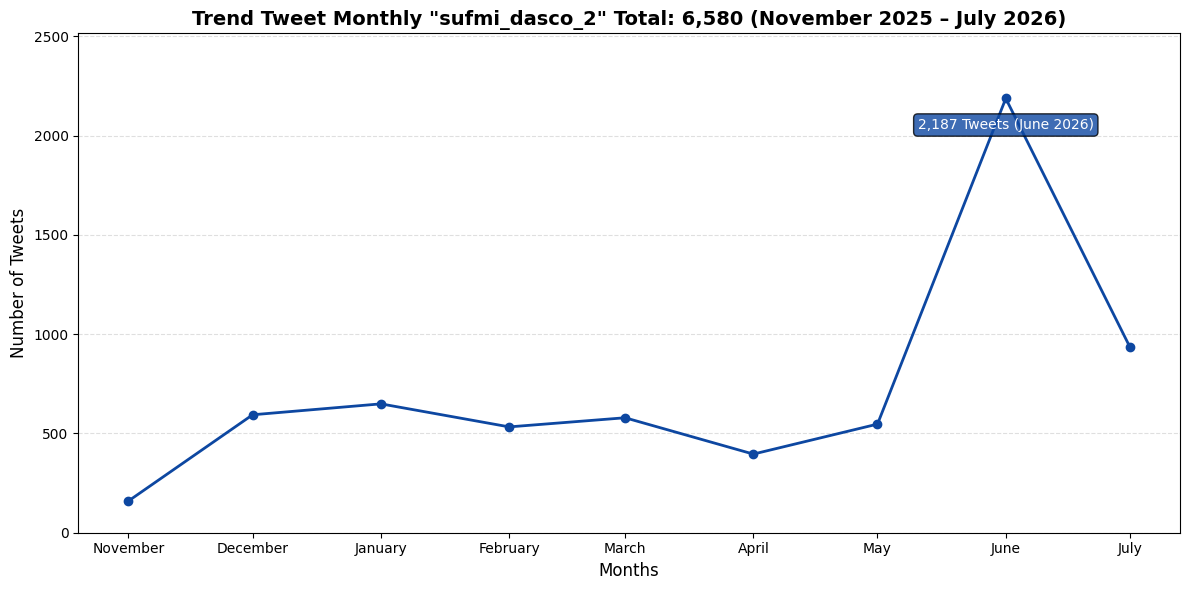

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# ======== Hitung jumlah tweet per bulan ========
df_filtered["bulan"] = df_filtered["tanggal"].dt.to_period("M").dt.to_timestamp()
monthly_counts = df_filtered.groupby("bulan").size().sort_index()

# ======== Cek jika data kosong ========
if monthly_counts.empty:
    print("Tidak ada data yang bisa ditampilkan dalam rentang waktu ini.")
else:
    # ======== Plot ========
    plt.figure(figsize=(12,6))
    plt.plot(monthly_counts.index, monthly_counts, color="#0D47A1", linewidth=2, marker="o")

    # ======== Format X-axis ========
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=0, ha="center")

    # ======== Temukan puncak data ========
    max_value = monthly_counts.max()
    max_months = monthly_counts[monthly_counts == max_value].index

    if len(max_months) > 1:
        start_peak = max_months.min()
        end_peak = max_months.max()
        label_text = f"{max_value:,} Tweets ({start_peak.strftime('%B')} – {end_peak.strftime('%B %Y')})"
        peak_date = start_peak + (end_peak - start_peak) / 2
    else:
        peak_date = max_months[0]
        label_text = f"{max_value:,} Tweets ({peak_date.strftime('%B %Y')})"

    # ======== Atur batas atas Y agar label tidak keluar ========
    y_margin = max_value * 0.15
    plt.ylim(0, max_value + y_margin)

    # ======== Tambahkan label di dalam frame ========
    plt.text(
        peak_date, max_value - (y_margin * 0.3),
        label_text,
        ha="center", va="top",
        fontsize=10, color="white",
        bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
    )

    # ======== Styling ========
    plt.title(f"Trend Tweet Monthly \"{project_name}\" Total: {int(len(df)):,} ({start_date.strftime('%B %Y')} – {end_date.strftime('%B %Y')})", fontsize=14, fontweight="bold")
    plt.xlabel("Months", fontsize=12)
    plt.ylabel("Number of Tweets", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    # ======== Save Figure ========
    plt.savefig(f"{output_folder}/{project_name}_trend_tweet_monthly.png", dpi=300, bbox_inches="tight")

    plt.show()

# ======== Simpan CSV Bulanan ========
monthly_df = monthly_counts.reset_index()
monthly_df.columns = ["bulan", "jumlah_data"]
monthly_df["bulan"] = monthly_df["bulan"].dt.strftime("%B %Y")
monthly_df.to_csv(f"{output_folder}/{project_name}_tweet_per_bulan.csv", index=False)

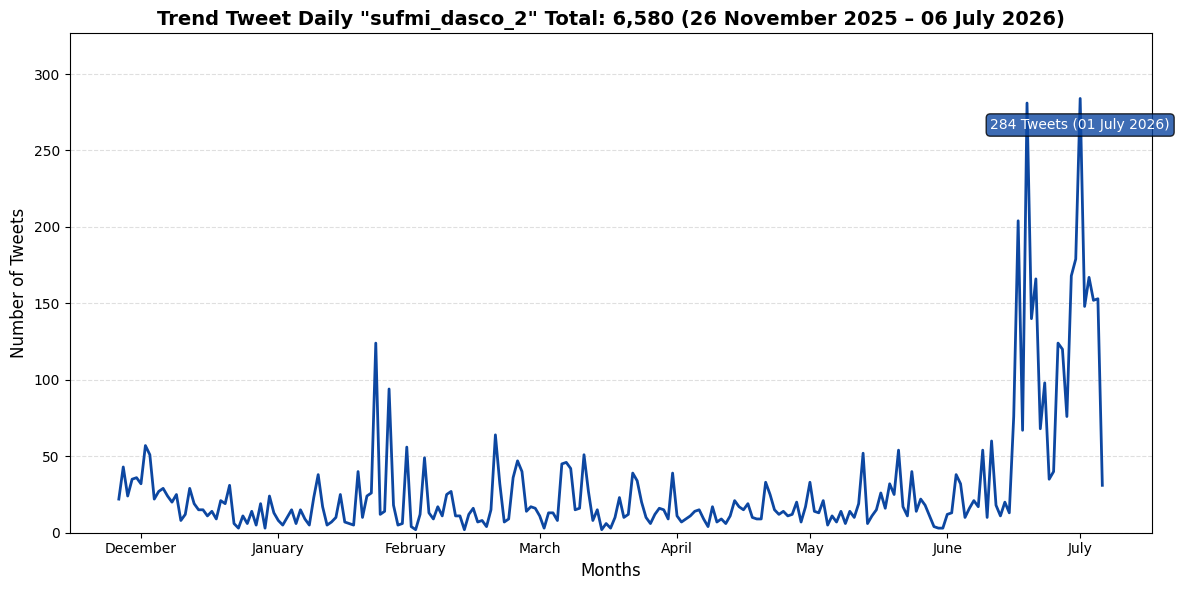

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# Hitung jumlah tweet per tanggal
daily_counts = df_filtered.groupby("tanggal").size().sort_index()

# Hitung durasi total hari
total_days = (daily_counts.index.max() - daily_counts.index.min()).days

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, color="#0D47A1", linewidth=2,)

# ======== Format X-axis adaptif ========
ax = plt.gca()

if total_days < 14:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
elif total_days < 31:
# else:
    week_labels = []
    current_month = None
    week_counter = 1
    last_label_date = None
    for date in daily_counts.index:
        if current_month != date.strftime("%b"):
            current_month = date.strftime("%b")
            week_counter = 1
        if last_label_date is None or (date - last_label_date).days >= 7:
            week_labels.append(f"{current_month} W{week_counter}")
            week_counter += 1
            last_label_date = date
        else:
            week_labels.append("")
    plt.xticks(daily_counts.index, week_labels, rotation=0, ha="center")
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())


# ======== Temukan puncak data ========
max_value = daily_counts.max()
max_dates = daily_counts[daily_counts == max_value].index

if len(max_dates) > 1:
    start_peak = max_dates.min()
    end_peak = max_dates.max()
    label_text = f"{max_value:,} Tweets ({start_peak.strftime('%d %B')} – {end_peak.strftime('%d %B')})"
    peak_date = start_peak + (end_peak - start_peak) / 2
else:
    peak_date = max_dates[0]
    label_text = f"{max_value:,} Tweets ({peak_date.strftime('%d %B %Y')})"

# ======== Atur batas atas Y agar label tidak keluar ========
y_margin = max_value * 0.15
plt.ylim(0, max_value + y_margin)

# ======== Tambahkan label di dalam frame ========
plt.text(
    peak_date, max_value - (y_margin * 0.3),
    label_text,
    ha="center", va="top",
    fontsize=10, color="white",
    bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
)

# ======== Styling ========
plt.title(f"Trend Tweet Daily \"{project_name}\" Total: {int(len(df)):,} ({start_date.strftime('%d %B %Y')} – {end_date.strftime('%d %B %Y')})", fontsize=14, fontweight="bold")
plt.xlabel("Months", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# ======== Save Figure ========
plt.savefig(f"{output_folder}/{project_name}_trend_tweet_daily.png", dpi=300, bbox_inches="tight")

plt.show()


In [5]:
# CASE FOLDING
def case_folding(tweet):
  if isinstance(tweet, str):
    lowerCase = tweet.lower()
    return lowerCase

df['case_folding'] = df['full_text'].apply(case_folding)

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,reply_count,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,0,0,0,-,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,1,0,0,https://pbs.twimg.com/media/HMgfNTtbUAAHTSa.jpg,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,0,1,0,-,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,0,0,0,-,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,0,0,0,-,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...


In [6]:
# NORMALIZE
def normalize(text, kamus):
    import re

    if not isinstance(text, str):
        return "", [], [], []

    # Cleansing ringan
    text = re.sub(r'^rt[\s]+', ' ', text)
    text = re.sub(r'@[^\s]+', ' ', text)
    text = re.sub(r'#[^\s]+', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"  # dingbats
        "\U000024C2-\U0001F251"  # enclosed chars
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    text = re.sub(r'&gt;', ' ', text)
    text = re.sub(r'&amp;|&', ' ', text)
    text = re.sub(r'amp[\s]+', ' ', text)
    text = re.sub(r'[^\w\s:%$.\-,!?/\"\\\']', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Normalize slang words
    replaced_words = []
    kata_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []
    sorted_patterns = sorted(kamus.keys(), key=len, reverse=True)

    for slang in sorted_patterns:
        pattern = re.compile(rf'\b{re.escape(slang)}\b')
        matches = pattern.findall(text)
        if matches:
            for match in matches:
                kata_diganti.append(match)
                kata_tidak_baku_hash.append(match)
            text = pattern.sub(kamus[slang], text)
            kata_baku.extend([kamus[slang]] * len(matches))

    return text, kata_baku, kata_diganti, kata_tidak_baku_hash


# Load kamus
kamus_kata = pd.read_csv("https://raw.githubusercontent.com/whdkelilauw/myfiles/main/kamus_normalize.csv")
kamus_kata['slang'] = kamus_kata['slang'].str.strip()
kamus_kata['formal'] = kamus_kata['formal'].str.strip()
kamus = dict(zip(kamus_kata['slang'], kamus_kata['formal']))

df['normalize'] = df['case_folding'].apply(lambda x: normalize(x, kamus)[0])

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,normalize
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,0,0,-,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,0,0,https://pbs.twimg.com/media/HMgfNTtbUAAHTSa.jpg,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,1,0,-,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,0,0,-,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,0,0,-,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...


In [7]:
# CLEANSING
def cleansing(tweet):
  tweet = tweet.encode('ascii', 'replace').decode('ascii') # Remove ASCII
  tweet = re.sub(r'[0-9]+', '', tweet) # Remove angka
  tweet = re.sub(r'^rt[\s]+', ' ', tweet) # Remove retweet marker (RT)
  tweet = re.sub(r'@[^\s]+', ' ', tweet)  # Remove Mention
  tweet = re.sub(r'#[^\s]+', ' ', tweet)  # Remove tagar
  tweet = re.sub(r'http\S+|www\.\S+', '', tweet)  # Remove URL
  emoji_pattern = re.compile(
      "["
      "\U0001F600-\U0001F64F"  # Emoticons
      "\U0001F300-\U0001F5FF"  # Symbols & pictographs
      "\U0001F680-\U0001F6FF"  # Transport & map symbols
      "\U0001F1E0-\U0001F1FF"  # Flags
      "\U00002702-\U000027B0"  # Dingbats
      "\U000024C2-\U0001F251"  # Enclosed characters
      "]+", flags=re.UNICODE)
  tweet = emoji_pattern.sub(r'', tweet)
  tweet = re.sub(r'[^\w\s]', ' ', tweet) # Remove tanda baca
  tweet = re.sub(r'&amp;|&', ' ', tweet) # Remove &amp atau & secara umum
  tweet = re.sub(r'amp[\s]+', ' ', tweet) # Remove amp
  tweet = re.sub(r'\s+', ' ', tweet).strip() # Remove whitespace berlebih
  return tweet

df['cleansing'] = df['normalize'].apply(lambda x: normalize(cleansing(x), kamus)[0])

df = df[df['cleansing'].notna() & (df['cleansing'].str.strip() != "-") & (df['cleansing'].str.strip() != "")]
df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,normalize,cleansing
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,0,-,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...,saya masih ada ide tentang pengawasan bandar n...
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,0,https://pbs.twimg.com/media/HMgfNTtbUAAHTSa.jpg,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...",kuasa hukum nadiem makarim ari yusuf amir mere...
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,0,-,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...",jadi nyomot manusia random untuk didudukkan se...
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,0,-,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...,dipertanyakan sikap presiden menlu thd iran se...
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,0,-,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...,lhah memang mereka gerombolan omon omon apa ya...


In [8]:
# TOKENIZE
def tokenize(text):
  token = text.split()
  return token

df['tokenize'] = df['cleansing'].apply(tokenize)
df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,normalize,cleansing,tokenize
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,-,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...,saya masih ada ide tentang pengawasan bandar n...,"[saya, masih, ada, ide, tentang, pengawasan, b..."
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,https://pbs.twimg.com/media/HMgfNTtbUAAHTSa.jpg,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...",kuasa hukum nadiem makarim ari yusuf amir mere...,"[kuasa, hukum, nadiem, makarim, ari, yusuf, am..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,-,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...",jadi nyomot manusia random untuk didudukkan se...,"[jadi, nyomot, manusia, random, untuk, diduduk..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,-,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...,dipertanyakan sikap presiden menlu thd iran se...,"[dipertanyakan, sikap, presiden, menlu, thd, i..."
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,-,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...,lhah memang mereka gerombolan omon omon apa ya...,"[lhah, memang, mereka, gerombolan, omon, omon,..."


In [9]:
# STOPWORD REMOVAL
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = stopwords.words('indonesian')

CUSTOM_STOPWORDS = [
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z',
    'aww','awww','tu','tuh','uf','deh','dah','amp','je','rm','ufcc','ppv','of',
    'sih','eh','hm','hmm','hmmm','nya','kah','kan','kalo','kayak','doang','dll','tau',
    'ufufuf','lho','loh','lah','pon','je','pe','gs','ya','go','bro',
    'mah','lu','lo','loe','kau','ku','kuu','tau','ni','nih','gue','gua','gw',
    'kah','kahh','kak','kakk','kakak','kaka','kakkk','wkwk','wkwkwk','wkwkwkwk',
    'bang','abang','guy','guys','gaes','bawa','sok','pas','iya'
]

stop_words.extend(CUSTOM_STOPWORDS)

sw = set(stop_words)

def stopword_removal(text):
  return [word for word in text if word not in sw]

df['stopword_removal'] = df['tokenize'].apply(stopword_removal)

df = df[df['stopword_removal'].notna() & (df['stopword_removal'].str.len() > 0)]
df.head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,normalize,cleansing,tokenize,stopword_removal
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,https://x.com/tentaralangit99/status/207394750...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...,saya masih ada ide tentang pengawasan bandar n...,"[saya, masih, ada, ide, tentang, pengawasan, b...","[ide, pengawasan, bandar, narkoba, pencegahan,..."
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,https://x.com/tribunnews/status/20739420899399...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...",kuasa hukum nadiem makarim ari yusuf amir mere...,"[kuasa, hukum, nadiem, makarim, ari, yusuf, am...","[kuasa, hukum, nadiem, makarim, ari, yusuf, am..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,https://x.com/NephilaXmus/status/2073941922813...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...",jadi nyomot manusia random untuk didudukkan se...,"[jadi, nyomot, manusia, random, untuk, diduduk...","[nyomot, manusia, random, didudukkan, komisari..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,https://x.com/info_edubisnis/status/2073941171...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...,dipertanyakan sikap presiden menlu thd iran se...,"[dipertanyakan, sikap, presiden, menlu, thd, i...","[sikap, presiden, menlu, thd, iran, negara, sa..."
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,https://x.com/Ary_LFC/status/2073925491455848905,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...,lhah memang mereka gerombolan omon omon apa ya...,"[lhah, memang, mereka, gerombolan, omon, omon,...","[lhah, gerombolan, omon, omon, mulut, silit]"


In [10]:
# STEMMING
factory = StemmerFactory()
stemmer = factory.create_stemmer()

custom_dict = {
  "kinerja": "kinerja",
  "pemerintah": "pemerintah",
  "pemerintahan": "pemerintah"
}

def stemming(text):
  if isinstance(text, list):
    stemmed_words = []
    for word in text:
      if word in custom_dict:
        stemmed_words.append(custom_dict[word])
      else:
        stemmed_words.append(stemmer.stem(word))
    return stemmed_words
  else:
    return ""

df['stemming'] = df['stopword_removal'].apply(stemming)
df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,relation_type,target_tweet_id_str,target_username,full_text,case_folding,normalize,cleansing,tokenize,stopword_removal,stemming
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,replied,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...,saya masih ada ide tentang pengawasan bandar n...,"[saya, masih, ada, ide, tentang, pengawasan, b...","[ide, pengawasan, bandar, narkoba, pencegahan,...","[ide, awas, bandar, narkoba, cegah, edar, nark..."
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,-,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...",kuasa hukum nadiem makarim ari yusuf amir mere...,"[kuasa, hukum, nadiem, makarim, ari, yusuf, am...","[kuasa, hukum, nadiem, makarim, ari, yusuf, am...","[kuasa, hukum, nadiem, makarim, ari, yusuf, am..."
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,quoted,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...",jadi nyomot manusia random untuk didudukkan se...,"[jadi, nyomot, manusia, random, untuk, diduduk...","[nyomot, manusia, random, didudukkan, komisari...","[nyomot, manusia, random, duduk, komisaris, le..."
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,quoted,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...,dipertanyakan sikap presiden menlu thd iran se...,"[dipertanyakan, sikap, presiden, menlu, thd, i...","[sikap, presiden, menlu, thd, iran, negara, sa...","[sikap, presiden, menlu, thd, iran, negara, sa..."
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,replied,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...,lhah memang mereka gerombolan omon omon apa ya...,"[lhah, memang, mereka, gerombolan, omon, omon,...","[lhah, gerombolan, omon, omon, mulut, silit]","[lhah, gerombol, omon, omon, mulut, silit]"


In [11]:
# INDOBERTWEET-SENTIMENT-ANALYSIS
tokenizer = AutoTokenizer.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")

label_map = {0: "negative", 1: "neutral", 2: "positive"}

def predict_sentiment(texts, batch_size=32):
  all_preds = []
  all_scores = []

  for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                        padding=True, max_length=128)

    with torch.no_grad():
      outputs = model(**inputs)
      probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
      preds = torch.argmax(probs, dim=1)

    for j in range(len(batch_texts)):
      pred_idx = preds[j].item()
      all_preds.append(label_map[pred_idx])
      all_scores.append(probs[j][pred_idx].item())

  return all_preds, all_scores

sentiments, scores = predict_sentiment(df['normalize'].tolist())
df['sentiment'] = sentiments
df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,target_tweet_id_str,target_username,full_text,case_folding,normalize,cleansing,tokenize,stopword_removal,stemming,sentiment
0,2073947500592112020,Mon Jul 06 08:49:50 +0700 2026,2026-07-06,08:49:50,1366760393792581636,tentaralangit99,mahkota99,@OmJ_J3Nggott;@prabowo;@bang_dasco,-,Indonesia,...,2073642298144080164,OmJ_J3Nggott,@OmJ_J3Nggott Saya masih ada ide tentang penga...,@omj_j3nggott saya masih ada ide tentang penga...,saya masih ada ide tentang pengawasan bandar n...,saya masih ada ide tentang pengawasan bandar n...,"[saya, masih, ada, ide, tentang, pengawasan, b...","[ide, pengawasan, bandar, narkoba, pencegahan,...","[ide, awas, bandar, narkoba, cegah, edar, nark...",neutral
1,2073942089939968379,Mon Jul 06 08:28:20 +0700 2026,2026-07-06,08:28:20,124171593,tribunnews,Tribunnews.com,-,-,Indonesia,...,-,-,"Kuasa hukum Nadiem Makarim, Ari Yusuf Amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...","kuasa hukum nadiem makarim, ari yusuf amir mer...",kuasa hukum nadiem makarim ari yusuf amir mere...,"[kuasa, hukum, nadiem, makarim, ari, yusuf, am...","[kuasa, hukum, nadiem, makarim, ari, yusuf, am...","[kuasa, hukum, nadiem, makarim, ari, yusuf, am...",neutral
2,2073941922813505960,Mon Jul 06 08:27:41 +0700 2026,2026-07-06,08:27:41,62764588,NephilaXmus,nephilaXmus,@bumn_idn;@prabowo;@KSPgoid;@bang_dasco,-,Indonesia,...,2073927582953701859,VIVAcoid,"Jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...","jadi, nyomot manusia random untuk didudukkan s...",jadi nyomot manusia random untuk didudukkan se...,"[jadi, nyomot, manusia, random, untuk, diduduk...","[nyomot, manusia, random, didudukkan, komisari...","[nyomot, manusia, random, duduk, komisaris, le...",negative
3,2073941171664244758,Mon Jul 06 08:24:41 +0700 2026,2026-07-06,08:24:41,3152238055,info_edubisnis,INFO_EkoBis_Humaniora,@prabowo;@Menlu_RI;@bang_dasco;@Yusrilihza_Mhd...,-,-,...,2073745310632071510,dina_sulaeman,Dipertanyakan SIKAP Presiden &amp; Menlu thd I...,dipertanyakan sikap presiden &amp; menlu thd i...,dipertanyakan sikap presiden menlu thd iran se...,dipertanyakan sikap presiden menlu thd iran se...,"[dipertanyakan, sikap, presiden, menlu, thd, i...","[sikap, presiden, menlu, thd, iran, negara, sa...","[sikap, presiden, menlu, thd, iran, negara, sa...",negative
4,2073925491455848905,Mon Jul 06 07:22:23 +0700 2026,2026-07-06,07:22:23,113004838,Ary_LFC,Ary LFC,@Faraz_kepri;@regar_op0sisi;@prabowo;@Gerindra...,-,"Liverpool, England",...,2073827545364287897,Faraz_kepri,@Faraz_kepri @regar_op0sisi @prabowo @Gerindra...,@faraz_kepri @regar_op0sisi @prabowo @gerindra...,lhah memang mereka gerombolan omon-omon... apa...,lhah memang mereka gerombolan omon omon apa ya...,"[lhah, memang, mereka, gerombolan, omon, omon,...","[lhah, gerombolan, omon, omon, mulut, silit]","[lhah, gerombol, omon, omon, mulut, silit]",negative


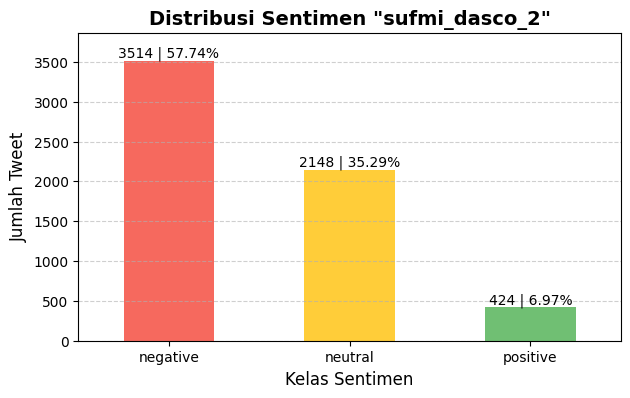

In [12]:
# DISTRIBUSI SENTIMEN BARCHART
color_map = {
    "negative": "#F44336",
    "neutral": "#FFC107",
    "positive": "#4CAF50"
}

sentiment_counts = df["sentiment"].value_counts()

colors = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(7,4))
bars = sentiment_counts.plot(
    kind="bar",
    color=colors,
    alpha=0.8
)

for i, v in enumerate(sentiment_counts):
    pct = (v / len(df['sentiment'])) * 100
    plt.text(i, v, f"{v} | {pct:.2f}%", ha="center", va="bottom", fontsize=10)

plt.title(f"Distribusi Sentimen \"{project_name}\"", fontsize=14, fontweight="bold")
plt.xlabel("Kelas Sentimen", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(sentiment_counts) * 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig(f"{output_folder}/{project_name}_barchart_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

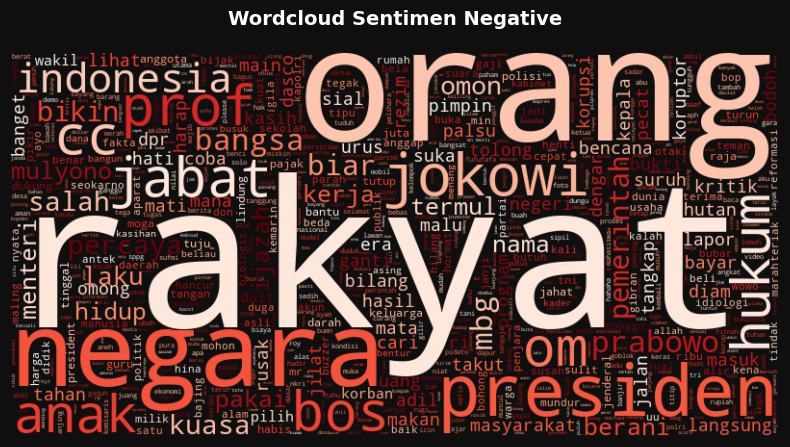

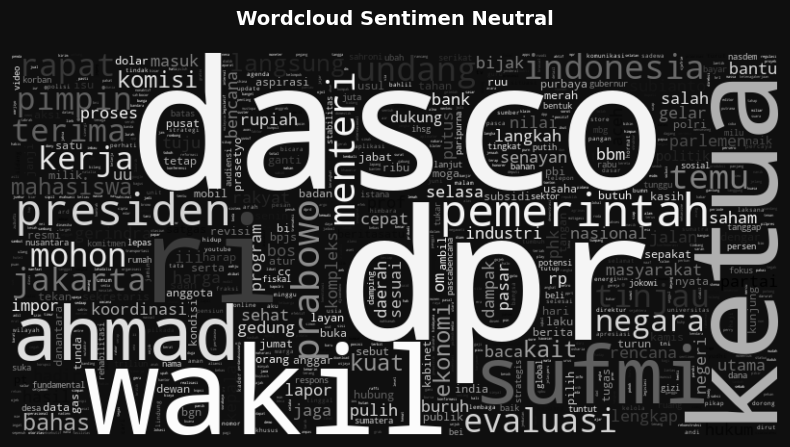

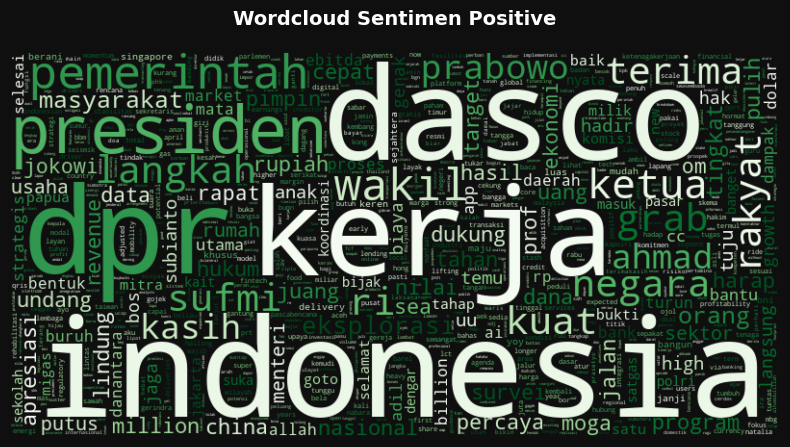

In [13]:
# WORDCLOUD 
sw = set(STOPWORDS)
sw.update(CUSTOM_STOPWORDS)
sw.update([''])

SENTIMENT_COLORMAP = {
    "negative": "Reds",
    "positive": "Greens",
    "neutral":  "Greys"
}
DARK_BG = "#0f0f0f"
TITLE_COLOR = "white"

def generate_wordcloud_by_sentiment(df, sentiment_label, output_folder, project_name):
    subset = df[df['sentiment'] == sentiment_label]

    if subset.empty:
        print(f"[INFO] Tidak ada data untuk sentimen: {sentiment_label}")
        return

    tokens = subset['stemming'].explode().dropna()
    tokens = tokens[~tokens.isin(sw)]
    text = Counter(tokens)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color=DARK_BG,
        contour_width=0,
        colormap=SENTIMENT_COLORMAP.get(sentiment_label, "gray"),
        max_words=800,
        random_state=42
    ).generate_from_frequencies(text)

    fig = plt.figure(figsize=(8,6), facecolor=DARK_BG)
    plt.imshow(wordcloud, interpolation='bilinear')

    plt.title(
        f"Wordcloud Sentimen {sentiment_label.capitalize()}",
        fontsize=14,
        fontweight="bold",
        color=TITLE_COLOR,
        pad=20
    )

    plt.axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(
        f"{output_folder}/{project_name}_wordcloud_{sentiment_label}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()

for s in ['negative', 'neutral', 'positive']:
    generate_wordcloud_by_sentiment(
        df,
        sentiment_label=s,
        output_folder=output_folder,
        project_name=project_name
    )

In [14]:
import pandas as pd
from collections import Counter
from wordcloud import STOPWORDS

# base + custom stopwords
sw = set(STOPWORDS)
sw.update(CUSTOM_STOPWORDS)
sw.update([''])

# explode list → filter stopwords
tokens = df['stemming'].explode().dropna()
tokens = tokens[~tokens.isin(sw)]

# hitung frekuensi
counter = Counter(tokens)
top_500 = counter.most_common(500)

# ubah urutan kolom → weight dulu, baru word
df_out = pd.DataFrame(
    [(freq, word) for word, freq in top_500],
    columns=['weight', 'word']
)

df_out.to_csv(f'{output_folder}/{project_name}_wordcloud_data.csv', index=False)

print(f"{project_name}_wordcloud_data.csv berhasil dibuat.")

sufmi_dasco_2_wordcloud_data.csv berhasil dibuat.


In [15]:
# SIMPAN HASIL
df.to_csv(f"{output_folder}/prep_{file_name}", index=False, encoding="utf-8")

# SPLIT DATA BY TANGGAL

### Cek Ideal Timeframe

In [ ]:
import os
import pandas as pd

project_name = "adi_sawit"
file_name = f"prep_{project_name}-tweets.csv"

# Setup folder
base_folder = f"../../result/{project_name}/tweets/preprocessing"
os.makedirs(base_folder, exist_ok=True)

# Load data
data = pd.read_csv(
    f"{base_folder}/{file_name}",
    parse_dates=['tanggal']   # kolom tanggal
)

# Pastikan kolom tanggal sudah datetime
data['tanggal'] = pd.to_datetime(data['tanggal'])

# hitung jumlah tweet per hari
daily = data.groupby('tanggal').size().reset_index(name='count')
daily = daily.sort_values('tanggal').reset_index(drop=True)

# cari peak
peak_row = daily.loc[daily['count'].idxmax()]
peak_date = peak_row['tanggal']
peak_idx = daily.index[daily['tanggal'] == peak_date][0]

# tentukan window (jumlah hari sebelum dan sesudah peak_date)
window = 7

# === CARI RISE STARTS ===
rise_date = None
start_idx = max(0, peak_idx - window)

for i in range(start_idx, peak_idx - 2):
    # cek pola naik 2 hari berturut-turut
    if (daily.loc[i+1, 'count'] > daily.loc[i, 'count'] and
        daily.loc[i+2, 'count'] > daily.loc[i+1, 'count']):
        rise_date = daily.loc[i, 'tanggal']
        break

# === CARI FALL STARTS === 
after = daily[daily['tanggal'] > peak_date].copy()
after = after.reset_index(drop=True)

fall_date = None
turning_date = None

for i in range(1, len(after)):
    prev = after.loc[i-1, 'count']
    curr = after.loc[i, 'count']

    # deteksi mulai turun
    if fall_date is None and curr < prev:
        fall_date = after.loc[i, 'tanggal']

    # setelah turun, hentikan saat naik lagi
    if fall_date is not None and curr > prev:
        turning_date = after.loc[i, 'tanggal']
        break


since = (rise_date if rise_date is not None else peak_date).date()
until = (turning_date if turning_date is not None else peak_date).date()
print("Peak date:", peak_date.date())
print("Rise starts:", since)
print("Fall starts:", fall_date.date() if fall_date else None)
print("Fall ends (turning):", until)
print("=" * 60)
print(f"IDEAL TIMEFRAME = | since: {since} | until: {until} |")
print("=" * 60)

### Split Data

In [ ]:
# Input tanggal
since = "2026-01-18"
until = "2026-01-24"

# Filter data berdasarkan rentang tanggal
mask = (data['tanggal'] >= since) & (data['tanggal'] <= until)
filtered = data.loc[mask]

# Save ke CSV
output_path = f"{base_folder}/{project_name}_{since}_{until}_tweets.csv"
filtered.to_csv(output_path, index=False)

print("Saved:", output_path)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(output_path)

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# Hitung jumlah tweet per tanggal
daily_counts = df_filtered.groupby("tanggal").size().sort_index()

# Hitung durasi total hari
total_days = (daily_counts.index.max() - daily_counts.index.min()).days

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, color="#0D47A1", linewidth=2)

# ======== Format X-axis adaptif ========
ax = plt.gca()

if total_days < 14:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
elif total_days < 31:
    week_labels = []
    current_month = None
    week_counter = 1
    last_label_date = None
    for date in daily_counts.index:
        if current_month != date.strftime("%b"):
            current_month = date.strftime("%b")
            week_counter = 1
        if last_label_date is None or (date - last_label_date).days >= 7:
            week_labels.append(f"{current_month} W{week_counter}")
            week_counter += 1
            last_label_date = date
        else:
            week_labels.append("")
    plt.xticks(daily_counts.index, week_labels, rotation=45, ha="center")
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

# ======== Temukan puncak data ========
max_value = daily_counts.max()
max_dates = daily_counts[daily_counts == max_value].index

if len(max_dates) > 1:
    start_peak = max_dates.min()
    end_peak = max_dates.max()
    label_text = f"{max_value:,} Tweets ({start_peak.strftime('%d %B')} – {end_peak.strftime('%d %B')})"
    peak_date = start_peak + (end_peak - start_peak) / 2
else:
    peak_date = max_dates[0]
    label_text = f"{max_value:,} Tweets ({peak_date.strftime('%d %B %Y')})"

# ======== Atur batas atas Y agar label tidak keluar ========
y_margin = max_value * 0.15
plt.ylim(0, max_value + y_margin)

# ======== Tambahkan label di dalam frame ========
plt.text(
    peak_date, max_value - (y_margin * 0.3),
    label_text,
    ha="center", va="top",
    fontsize=10, color="white",
    bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
)

# ======== Styling ========
plt.title(f"Trend Tweet ({start_date.strftime('%d %B')} – {end_date.strftime('%d %B %Y')})", fontsize=14, fontweight="bold")
plt.xlabel("Dates", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# ======== Save Figure ========
plt.savefig(f"{base_folder}/trend_tweet_{since}_{until}.png", dpi=300, bbox_inches="tight")

plt.show()
